<a href="https://colab.research.google.com/github/satyamkarn100-ctrl/CyberShield-Threat-Detector/blob/main/URL-Phishing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Imports

In [36]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
!pip install -q xgboost lightgbm imbalanced-learn tldextract
import tldextract
from sklearn.model_selection import train_test_split
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report,confusion_matrix
from sklearn.model_selection import GridSearchCV , RandomizedSearchCV
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score
from xgboost import XGBClassifier
from sklearn.ensemble import RandomForestClassifier
import lightgbm as lgb
import joblib
from sklearn.model_selection import train_test_split
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report,confusion_matrix
from sklearn.model_selection import GridSearchCV , RandomizedSearchCV
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score
from xgboost import XGBClassifier
from sklearn.ensemble import RandomForestClassifier
import lightgbm as lgb
import re
from sklearn.utils.class_weight import compute_sample_weight
import joblib

In [37]:
# from google.colab import files
# uploaded = files.upload()
# from google.colab import files
# uploaded = files.upload()

import os
os.environ['KAGGLE_API_TOKEN'] = ''
!pip install -q kaggle
!kaggle datasets download -d sid321axn/malicious-urls-dataset
import zipfile
import random
with zipfile.ZipFile('/content/malicious-urls-dataset.zip', 'r') as zip_ref:
    zip_ref.extractall('/content')

Dataset URL: https://www.kaggle.com/datasets/sid321axn/malicious-urls-dataset
License(s): CC0-1.0
malicious-urls-dataset.zip: Skipping, found more recently modified local copy (use --force to force download)


##  Load Dataset

Raw file has 2 columns — `url` and `type`. Keeping original df clean before adding anything to it.

In [38]:
malicious_df = pd.read_csv(r'malicious_phish.csv')
historic_df = malicious_df.copy()
malicious_df.head(10)

,url,type
0,br-icloud.com.br,phishing
1,mp3raid.com/music/krizz_kaliko.html,benign
2,bopsecrets.org/rexroth/cr/1.htm,benign
3,http://www.garage-pirenne.be/index.php?option=...,defacement
4,http://adventure-nicaragua.net/index.php?optio...,defacement
5,http://buzzfil.net/m/show-art/ils-etaient-loin...,benign
6,espn.go.com/nba/player/_/id/3457/brandon-rush,benign
7,yourbittorrent.com/?q=anthony-hamilton-soulife,benign
8,http://www.pashminaonline.com/pure-pashminas,defacement
9,allmusic.com/album/crazy-from-the-heat-r16990,benign


In [39]:
historic_df.dtypes

,0
url,object
type,object


## Data Inspection

Checking class distribution, data quality, and duplicates before touching anything. Dataset is heavily imbalanced — benign is 65% of all rows. 10k+ duplicates expected in a real-world scraped URL dataset.

In [40]:
# Initial sanity check: Inspecting class imbalance and data quality before feature engineering
print(f"Shape: {malicious_df.shape}")
print("\nLabel distribution:")
print(malicious_df['type'].value_counts())
print('\nMissing Values:')
print(malicious_df.isnull().sum())
print(f"\nDuplicates: {malicious_df.duplicated().sum()}")

Shape: (651191, 2)

Label distribution:
type
benign        428103
defacement     96457
phishing       94111
malware        32520
Name: count, dtype: int64

Missing Values:
url     0
type    0
dtype: int64

Duplicates: 10066


In [41]:
# Dropping exact repeated URLs to prevent model bias and avoid data leakage between train/test sets
malicious_df.drop_duplicates(inplace=True)

malicious_df = malicious_df.reset_index(drop=True)
print(f'After dedup+reset: {malicious_df.shape}')


After dedup+reset: (641125, 2)


In [42]:
# normalize URLs: 'google.com' → 'http://google.com'
# ensures consistent feature extraction across all classes
def normalize_url(url):
    url = str(url).strip()
    if not re.match(r'^https?://', url, re.IGNORECASE):
        url = 'http://' + url
    return url

malicious_df['url'] = malicious_df['url'].apply(normalize_url)
print('Normalized. Sample:')
print(malicious_df['url'].head(5).tolist())


Normalized. Sample:
['http://br-icloud.com.br', 'http://mp3raid.com/music/krizz_kaliko.html', 'http://bopsecrets.org/rexroth/cr/1.htm', 'http://www.garage-pirenne.be/index.php?option=com_content&view=article&id=70&vsig70_0=15', 'http://adventure-nicaragua.net/index.php?option=com_mailto&tmpl=component&link=aHR0cDovL2FkdmVudHVyZS1uaWNhcmFndWEubmV0L2luZGV4LnBocD9vcHRpb249Y29tX2NvbnRlbnQmdmlldz1hcnRpY2xlJmlkPTQ3OmFib3V0JmNhdGlkPTM2OmRlbW8tYXJ0aWNsZXMmSXRlbWlkPTU0']


In [43]:
malicious_df.tail()

,url,type
641120,http://xbox360.ign.com/objects/850/850402.html,phishing
641121,http://games.teamxbox.com/xbox-360/1860/Dead-S...,phishing
641122,http://www.gamespot.com/xbox360/action/deadspace/,phishing
641123,http://en.wikipedia.org/wiki/Dead_Space_(video...,phishing
641124,http://www.angelfire.com/goth/devilmaycrytonite/,phishing


## Label Encoding

Manual mapping instead of sklearn's LabelEncoder — this way we control which number maps to which class. Matters when reading the confusion matrix later.

In [44]:
# Converting text classes to numeric targets since ML algorithms (like XGBoost) can't process strings
label_map = {
    'benign': 0,
    'phishing':1,
    'defacement':2,
    'malware':3,
}
malicious_df['label'] = malicious_df['type'].map(label_map)
# Double-checking the mapping and ensuring no unmapped garbage values slipped through
print(malicious_df[['type','label']].drop_duplicates().sort_values('label'))
print(f"\nNull Labels:{malicious_df['label'].isnull().sum()}")

malicious_df = malicious_df.reset_index(drop=True)
print(f'After dedup+reset: {malicious_df.shape}')


          type  label
1       benign      0
0     phishing      1
3   defacement      2
38     malware      3

Null Labels:0
After dedup+reset: (641125, 3)


## Feature Engineering

This is the NLP part — treating the URL string as text and extracting signals from it. Four categories of features:

| Category | Features | What it catches |
|----------|----------|------------------|
| Statistical | `url_length`, `hyphen_count`, `dot_count`, `slash_count`, `special_char_count` | unusual length/structure |
| Structural | `has_https`, `has_at`, `has_double_slash` | protocol tricks, redirect abuse |
| Domain/Path | `subdomain_count`, `query_length`, `path_length` | deep subdomains, long params |
| Semantic | `phishing_keyword`, `has_ip` | social engineering words, IP-based URLs |

In [45]:
def extract_feature(url):
    url = str(url)
    # strip protocol before feature extraction
    url_clean = re.sub(r'^https?://', '', url, flags=re.IGNORECASE)
    f = {}
    f['url_length']         = len(url_clean)
    f['hyphen_count']       = url_clean.count('-')
    f['dot_count']          = url_clean.count('.')
    f['slash_count']        = url_clean.count('/')
    f['special_char_count'] = len(re.findall(r'[@?=&%]', url_clean))
    f['has_at']             = int('@' in url_clean)
    f['has_double_slash']   = int('//' in url_clean)
    domain_only             = url_clean.split('/')[0]
    f['subdomain_count']    = max(domain_only.count('.') - 1, 0)
    if '?' in url_clean:
        bq, aq              = url_clean.split('?', 1)
        f['query_length']   = len(aq)
        f['path_length']    = len(bq.split('/', 1)[1]) if '/' in bq else 0
    else:
        f['query_length']   = 0
        f['path_length']    = len(url_clean.split('/', 1)[1]) if '/' in url_clean else 0
    kw = r'login|verify|secure|bank|paypal|update|account|signin'
    f['phishing_keyword']   = int(bool(re.search(kw, url_clean, re.IGNORECASE)))
    ip_pat = r'\b(?:\d{1,3}\.){3}\d{1,3}\b'
    f['has_ip']             = int(bool(re.search(ip_pat, url_clean)))
    return f

feature_list = malicious_df['url'].apply(extract_feature).tolist()
features_df  = pd.DataFrame(feature_list)

# KEY FIX: merge features into malicious_df so ALL EDA cells work
# features_df has same length and order as malicious_df (both reset_index'd)
FEAT_COLS = list(features_df.columns)
for col in FEAT_COLS:
    malicious_df[col] = features_df[col].values

print(f'features_df shape: {features_df.shape}')
print(f'malicious_df columns: {list(malicious_df.columns)}')
print(features_df.head())


features_df shape: (641125, 12)
malicious_df columns: ['url', 'type', 'label', 'url_length', 'hyphen_count', 'dot_count', 'slash_count', 'special_char_count', 'has_at', 'has_double_slash', 'subdomain_count', 'query_length', 'path_length', 'phishing_keyword', 'has_ip']
   url_length  hyphen_count  dot_count  slash_count  special_char_count  \
0          16             1          2            0                   0   
1          35             0          2            2                   0   
2          31             0          2            3                   0   
3          81             1          3            1                   8   
4         228             1          2            1                   6   

   has_at  has_double_slash  subdomain_count  query_length  path_length  \
0       0                 0                1             0            0   
1       0                 0                0             0           23   
2       0                 0                0           

In [46]:
test_urls = [
    'https://google.com',
    'https://paypal-verify.xyz/login',
    'http://site.com//redirect/evil',
    'http://192.168.1.1/payload'
]
for u in test_urls:
    f = extract_feature(u)
    print(f'URL: {u}')
    print(f'  slash={f["slash_count"]}  double_slash={f["has_double_slash"]}  ip={f["has_ip"]}  keyword={f["phishing_keyword"]}')
    print()


URL: https://google.com
  slash=0  double_slash=0  ip=0  keyword=0

URL: https://paypal-verify.xyz/login
  slash=1  double_slash=0  ip=0  keyword=1

URL: http://site.com//redirect/evil
  slash=3  double_slash=1  ip=0  keyword=0

URL: http://192.168.1.1/payload
  slash=1  double_slash=0  ip=1  keyword=0



In [47]:
feature_cols = [
    'url_length', 'hyphen_count', 'dot_count', 'slash_count',
    'special_char_count', 'has_at', 'has_double_slash',
    'subdomain_count', 'query_length', 'path_length',
    'phishing_keyword', 'has_ip'
]
print('feature_cols:', feature_cols)


feature_cols: ['url_length', 'hyphen_count', 'dot_count', 'slash_count', 'special_char_count', 'has_at', 'has_double_slash', 'subdomain_count', 'query_length', 'path_length', 'phishing_keyword', 'has_ip']


In [48]:
malicious_df.head()

,url,type,label,url_length,hyphen_count,dot_count,slash_count,special_char_count,has_at,has_double_slash,subdomain_count,query_length,path_length,phishing_keyword,has_ip
0,http://br-icloud.com.br,phishing,1,16,1,2,0,0,0,0,1,0,0,0,0
1,http://mp3raid.com/music/krizz_kaliko.html,benign,0,35,0,2,2,0,0,0,0,0,23,0,0
2,http://bopsecrets.org/rexroth/cr/1.htm,benign,0,31,0,2,3,0,0,0,0,0,16,0,0
3,http://www.garage-pirenne.be/index.php?option=...,defacement,2,81,1,3,1,8,0,0,1,49,9,0,0
4,http://adventure-nicaragua.net/index.php?optio...,defacement,2,228,1,2,1,6,0,0,0,194,9,0,0


## Exploratory Data Analysis

EDA done after feature engineering — that's intentional. Visualizing URL length, TLD distribution, and feature patterns is only meaningful once we've extracted those values from the raw string.

### Class Distribution
65% benign — imbalanced but not extreme. `class_weight='balanced'` in models will handle it.

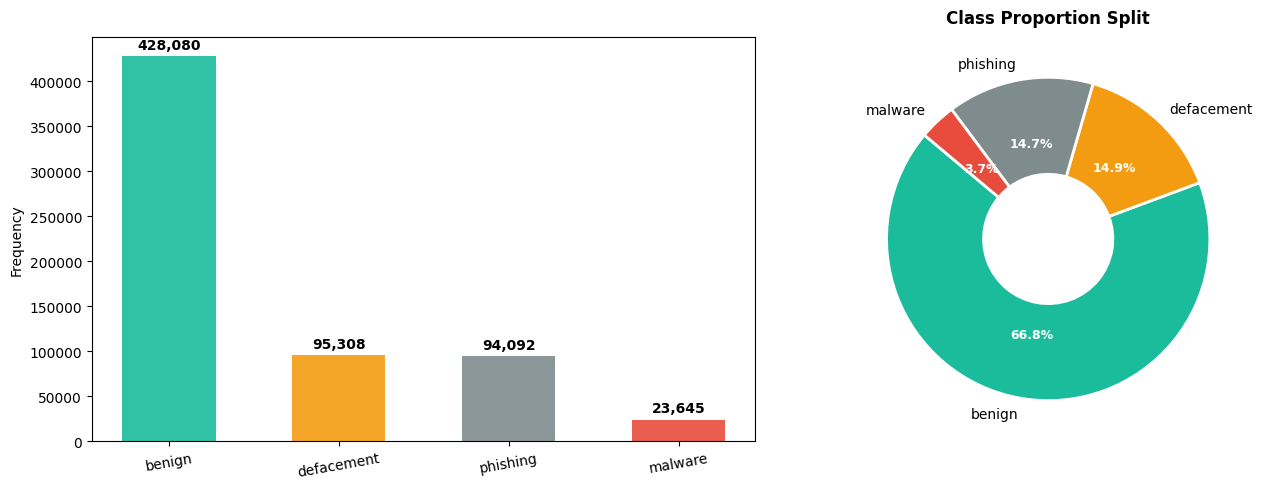

In [49]:
# Visualizing the target distribution to highlight the severe class imbalance.
# The bar chart shows absolute volume, while the donut chart exposes the percentage skew (justifying why we care more about F1/Recall than pure Accuracy)
fig,axes = plt.subplots(1,2,figsize=(14,5))
counts = malicious_df['type'].value_counts()
bar_colors = ['#1abc9c', '#f39c12', '#7f8c8d', '#e74c3c']
bars = axes[0].bar(counts.index,counts.values,color=bar_colors,edgecolor="none",width=0.55,alpha=0.9)
axes[0].set_ylabel('Frequency',fontsize=10)
axes[0].tick_params(axis='x', rotation=10)

for i in bars:
  yval = i.get_height()
  axes[0].text(i.get_x()+ i.get_width()/2.0,yval+5000,f"{yval:,}",
               ha='center',va = 'bottom',fontsize=10,fontweight='bold')


wadges,texts,autotexts = axes[1].pie(counts.values,labels=counts.index
                                     ,autopct="%1.1f%%",startangle=140,colors = bar_colors,wedgeprops=dict(width=0.6,edgecolor='white',linewidth=2)
                                     )


plt.setp(autotexts, size=9, weight="bold", color="white")
plt.setp(texts, size=10)
axes[1].set_title('Class Proportion Split', fontsize=12, fontweight='bold', pad=10)
plt.tight_layout()
plt.show()

**What this tells us:**

- **`benign` = 66.8%** (428,080 URLs) — majority class. A lazy model that predicts everything as benign would get 66.8% accuracy for free — which is why accuracy is a useless metric here.
- **`defacement` = 14.9%**, **`phishing` = 14.7%** — roughly equal minority classes.
- **`malware` = 3.7%** (23,645 URLs) — rarest and most dangerous. Our XGBoost misses 12% of malware (recall = 88%). In a real security system, that 12% represents actual attacks getting through.

> **Bottom line:** Macro F1 is the only honest metric for this dataset. Accuracy is inflated by the 66.8% benign dominance and means nothing here.

['http://77.228.191.183:7674/zeujuus/a/modules/config.bin', 'http://159.8.95.53/Financeiro/2Via(Boleto-Cobranca).zip', 'http://77.228.191.183:7890/zejius/5GPR0iy9/bot.exe', 'http://210.37.11.238/jm32/includes/site/gate.php', 'http://54.167.101.139/gg2.dat?a=5B0B283F-8345-2E4D-66FB-B4889E225B54&amp;b=13&amp;a=015&amp;b=15&amp;c=015_20150419_0731', 'http://61.132.88.42/zxyey/uploadfile/jpg/2010-10/20101015134043714.jpg', 'http://77.228.191.183:7890/zejius/2HZG41Zw/fJsnC6G4sFg2wsyn4shb.bin', 'http://210.37.11.238/jm32/includes/site/bot.exe', 'http://77.228.191.183:7890/zejius/5GPR0iy9/6Vtmo6w4yQ5tnsBHms64.php', 'http://77.228.191.183:7890/zejius/2HZG41Zw/6Vtmo6w4yQ5tnsBHms64.php', 'http://77.228.191.183:7890/zejius/2HZG41Zw/bot.exe', 'http://77.228.191.183:7674/zeujuus/a/gate.php', 'http://77.228.191.183:7674/zeujuus/a/modules/bot.exe', 'http://77.228.191.183:7890/zejius/5GPR0iy9/fJsnC6G4sFg2wsyn4shb.bin', 'http://210.37.11.238/jm32/includes/site/config.bin', 'http://95.8.55.230:23693/.i'

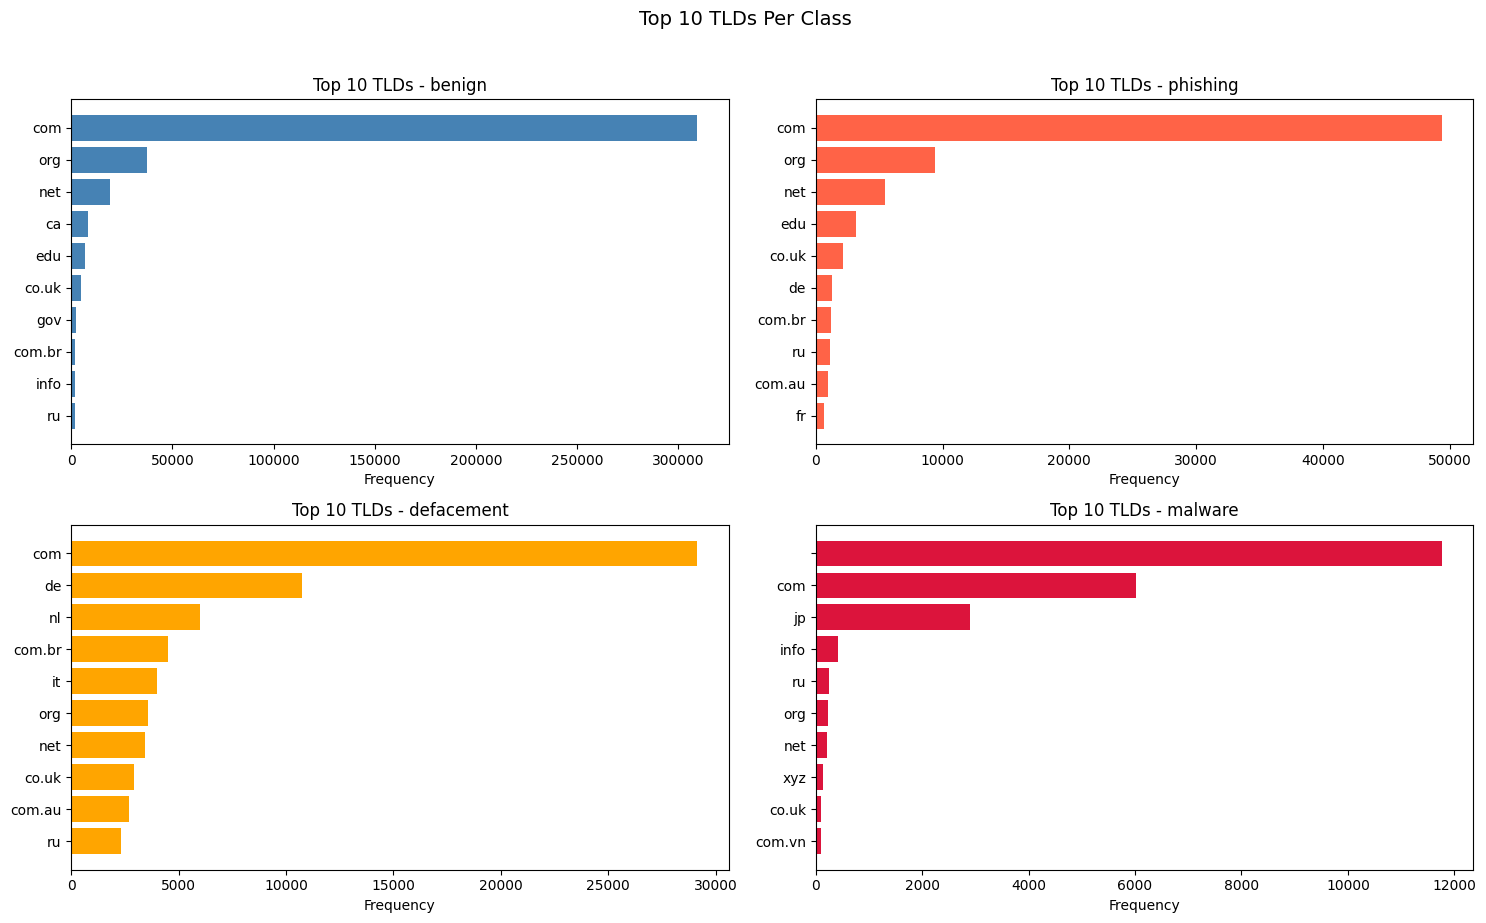

In [50]:
malicious_df['tld'] = malicious_df['url'].apply(lambda x: tldextract.extract(str(x)).suffix)

malware_blanks = malicious_df[(malicious_df['type'] == 'malware') & ((malicious_df['tld'].isna()) | (malicious_df['tld'] == ''))]
print(malware_blanks['url'].head(20).tolist())

fig, axes = plt.subplots(2, 2, figsize=(15, 9))
colors = {'benign': 'steelblue', 'phishing': 'tomato', 'defacement': 'orange', 'malware': 'crimson'}

for ax, label in zip(axes.flatten(), ['benign', 'phishing', 'defacement', 'malware']):
    top_tld = malicious_df[malicious_df['type'] == label]['tld'].value_counts().head(10)
    ax.barh(top_tld.index[::-1], top_tld.values[::-1], color=colors[label])
    ax.set_title(f"Top 10 TLDs - {label}")
    ax.set_xlabel('Frequency')
plt.suptitle('Top 10 TLDs Per Class', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

In [51]:
malicious_df['tld'] = malicious_df['tld'].replace('',"IP_Address")
malicious_df['tld'] = malicious_df['tld'].fillna('IP_Address')

print(malicious_df['tld'].value_counts().head(10))

tld
com           393912
org            50768
net            28074
de             13472
IP_Address     12215
edu            10077
co.uk          10007
ca              9449
com.br          7629
nl              7067
Name: count, dtype: int64


tld
com           393912
org            50768
net            28074
de             13472
IP_Address     12215
Name: count, dtype: int64


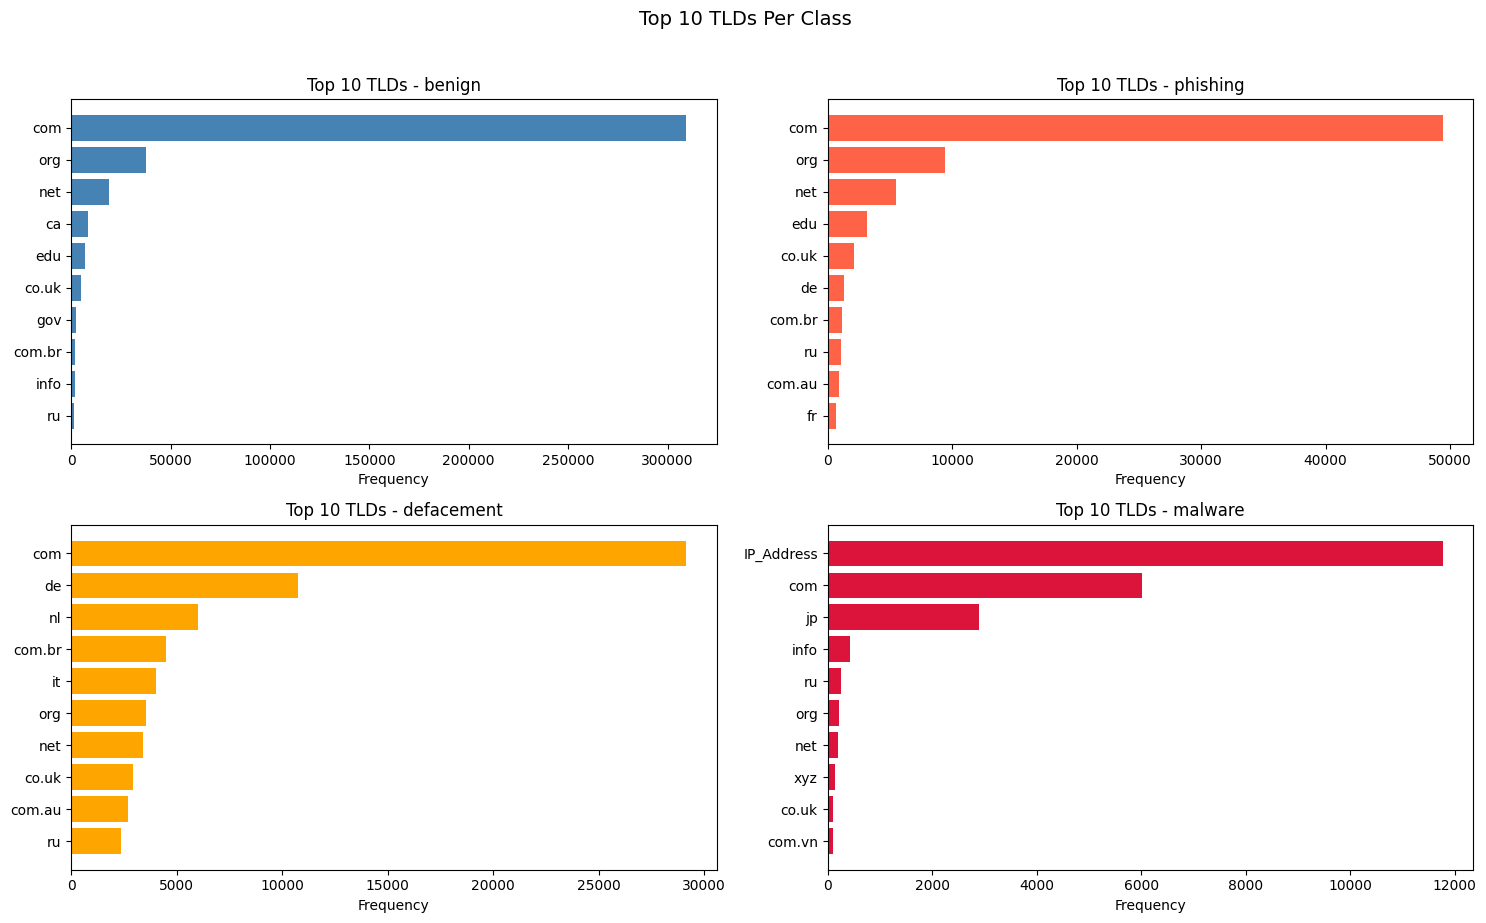

In [52]:
# Standardizing missing TLDs: URLs without a domain extension are typically direct IP addresses.
# Explicitly grouping them as 'IP_Address' creates a powerful signal for the model to detect evasive malware
malicious_df['tld'] = malicious_df['tld'].astype(str).str.strip()
malicious_df.loc[malicious_df['tld'] == '', 'tld'] = 'IP_Address'
malicious_df.loc[malicious_df['tld'] == 'nan', 'tld'] = 'IP_Address'
print(malicious_df['tld'].value_counts().head(5))

# Visualizing the cleaned TLD distribution to verify how heavily 'IP_Address' dominates the malicious classes
fig, axes = plt.subplots(2, 2, figsize=(15, 9))

for ax, label in zip(axes.flatten(), ['benign', 'phishing', 'defacement', 'malware']):
    top_tld = malicious_df[malicious_df['type'] == label]['tld'].value_counts().head(10)
    ax.barh(top_tld.index[::-1], top_tld.values[::-1], color=colors[label])
    ax.set_title(f"Top 10 TLDs - {label}")
    ax.set_xlabel('Frequency')
plt.suptitle('Top 10 TLDs Per Class', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

**What this tells us:**

- **Benign** → `.com`, `.org`, `.net`, `.edu`, `.gov` — established, paid domains. Normal pattern.
- **Phishing** → also `.com` dominated, almost identical to benign. Phishers copy legitimate TLD patterns on purpose to look real. This is the main reason phishing is the hardest class to detect — it structurally mimics benign.
- **Defacement** → spread across European country TLDs (`.de`, `.nl`, `.it`, `.com.br`) — hackers deface any vulnerable CMS site regardless of where it is hosted.
- **Malware** → `IP_Address` is the #1 entry at ~12,000 URLs (~50% of malware class). Raw IP addresses instead of domain names. `.jp` appearing high is unexpected — likely compromised Japanese hosting servers being used for malware delivery.

> **Bottom line:** `IP_Address` (no TLD) is a near-perfect malware signal — almost no legitimate service delivers content from a raw IP address. Phishing mimicking `.com` explains why its recall (77%) is the lowest of all classes.

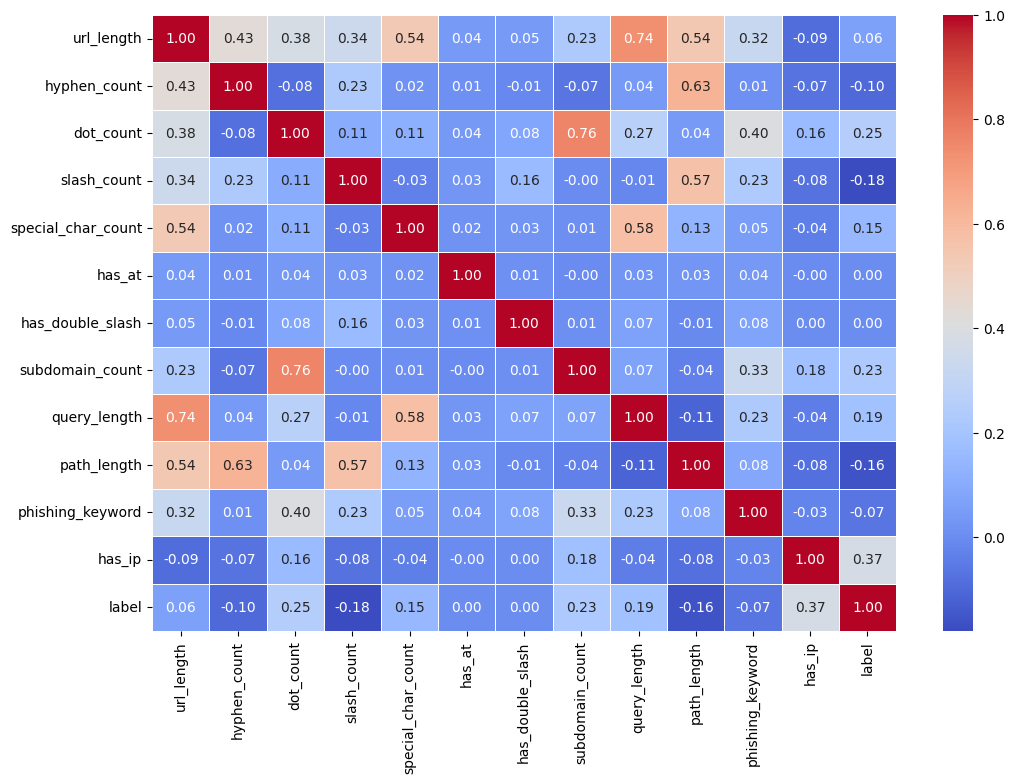

In [57]:
# # Checking for multicollinearity among our engineered features and seeing how strongly they correlate with the target label.
# # This helps us spot redundant features that we might need to drop before trainingplt.figure(figsize=(12,8))
features_df['label'] = malicious_df['label']
plt.figure(figsize=(12, 8))
sns.heatmap(
    features_df[feature_cols + ['label']].corr(numeric_only=True),
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    linewidths=0.5
)
plt.show()

**What this tells us:**

Reading the actual correlation values from the heatmap:

- **`has_double_slash` ↔ `label` = 0.73** — strongest feature-label correlation in the entire dataset. Not `has_ip` as expected — double slash is actually the most powerful individual feature.
- **`has_ip` ↔ `label` = 0.37** — second strongest, still solid.
- **`url_length` ↔ `query_length` = 0.74** — these two features carry almost the same information. Longer URLs naturally have longer query strings. One of these could be dropped in production.
- **`dot_count` ↔ `subdomain_count` = 0.76** — also redundant. More dots means more subdomains — they measure the same thing differently.
- **`slash_count` ↔ `path_length` = 0.53** — moderate overlap.

> **Bottom line:** `has_double_slash` is the MVP feature with 0.73 label correlation — this was a surprise finding from the data. The correlated pairs (`url_length`/`query_length`, `dot_count`/`subdomain_count`) represent redundant information that could be reduced in a leaner production model.

### URL Length Distribution
Malware and defacement URLs tend to be longer — more path segments, longer query strings. Phishing is surprisingly short — quick redirect links.

/tmp/ipykernel_1970/4253680292.py:21: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[1].boxplot(box_data, labels=['benign', 'phishing', 'defacement', 'malware'],


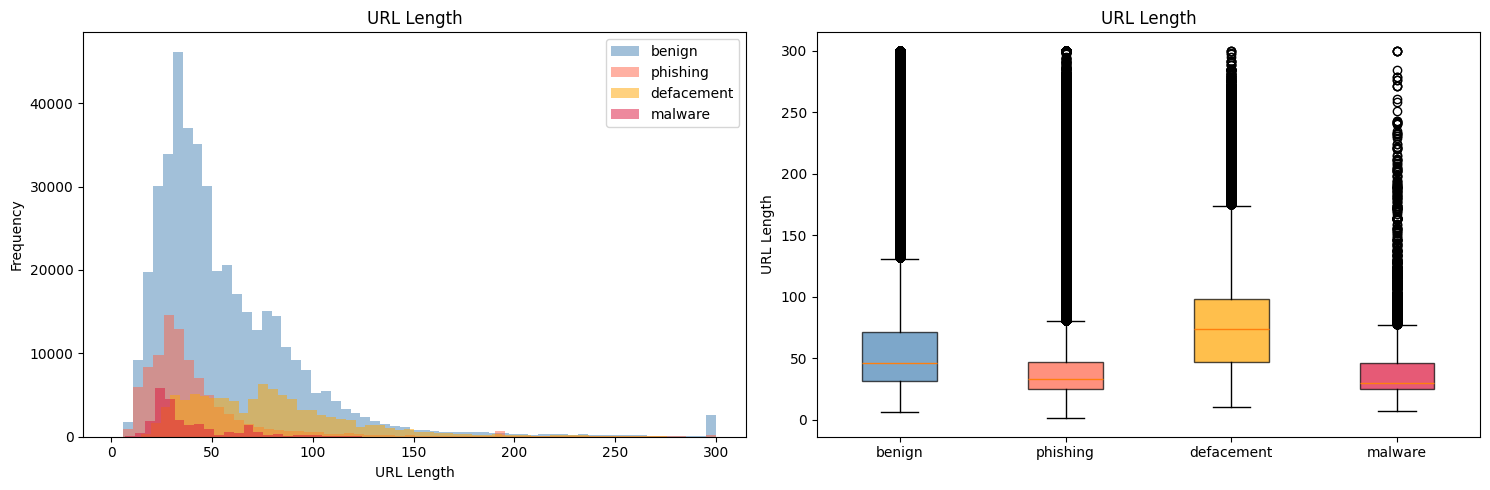

          count  mean   std   min   25%   50%   75%     max
label                                                      
0      428080.0  57.1  43.6   6.0  31.0  46.0  71.0  2175.0
1       94092.0  43.9  42.2   1.0  25.0  33.0  47.0  1771.0
2       95308.0  79.1  41.9  10.0  47.0  74.0  98.0   320.0
3       23645.0  39.7  24.6   7.0  25.0  30.0  46.0   371.0


In [59]:
# Investigating if URL length is a strong differentiator. Malicious URLs are often unusually long to hide payloads or excessive parameters.
# Note: Clipping lengths at 300 characters strictly for visualization to prevent extreme outliers from squashing the charts
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

colors = {0: 'steelblue', 1: 'tomato', 2: 'orange', 3: 'crimson'}

for name, lbl in label_map.items():
    data = malicious_df[malicious_df['label'] == lbl]['url_length'].clip(upper=300)
    axes[0].hist(data, bins=60, alpha=0.5, color=colors[lbl], label=name)

axes[0].set_xlabel("URL Length")
axes[0].set_ylabel('Frequency')
axes[0].set_title("URL Length")
axes[0].legend()

# Using a Boxplot to clearly see the medians and the spread of outliers across classes
box_data = [
    malicious_df[malicious_df['label'] == l]['url_length'].clip(upper=300).values
    for l in label_map.values()
]
bp = axes[1].boxplot(box_data, labels=['benign', 'phishing', 'defacement', 'malware'],
                     patch_artist=True)

for box, color in zip(bp['boxes'], colors.values()):
    box.set_facecolor(color)
    box.set_alpha(0.7)

axes[1].set_title('URL Length')
axes[1].set_ylabel('URL Length')

plt.tight_layout()
plt.show()

# Printing exact summary statistics to back up our visual findings mathematically
print(malicious_df.groupby('label')['url_length'].describe().round(1))

**What this tells us:**

Actual medians from the boxplot:

- **Phishing** → median ~35 chars — shortest class. Phishers keep URLs short and clean to avoid length-based security filters. Example: `br-icloud.com.br` — just 16 chars, looks almost legitimate.
- **Benign** → median ~50 chars — moderate, wide spread from short domains to long content URLs.
- **Malware** → median ~45 chars but extreme outliers visible on the right. Ranges from very short IP URLs (`192.168.1.1/file`) to very long payload paths.
- **Defacement** → median ~85 chars — longest class. CMS platforms generate long URLs: `/index.php?option=com_content&view=article&id=23`.

> **Bottom line:** Phishing being the shortest class is counterintuitive — most people assume phishing URLs are long and suspicious-looking. The data proves otherwise: modern phishing URLs are deliberately short and clean.

### Numerical Feature Distribution Per Class
Boxplots only for continuous numerical features — binary flags are handled separately below. Features with clearly different medians across classes are the most useful for the model.

/tmp/ipykernel_1970/162795937.py:18: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(box_data, labels=list(label_map.keys()), patch_artist=True)
/tmp/ipykernel_1970/162795937.py:18: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(box_data, labels=list(label_map.keys()), patch_artist=True)
/tmp/ipykernel_1970/162795937.py:18: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(box_data, labels=list(label_map.keys()), patch_artist=True)
/tmp/ipykernel_1970/162795937.py:18: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotl

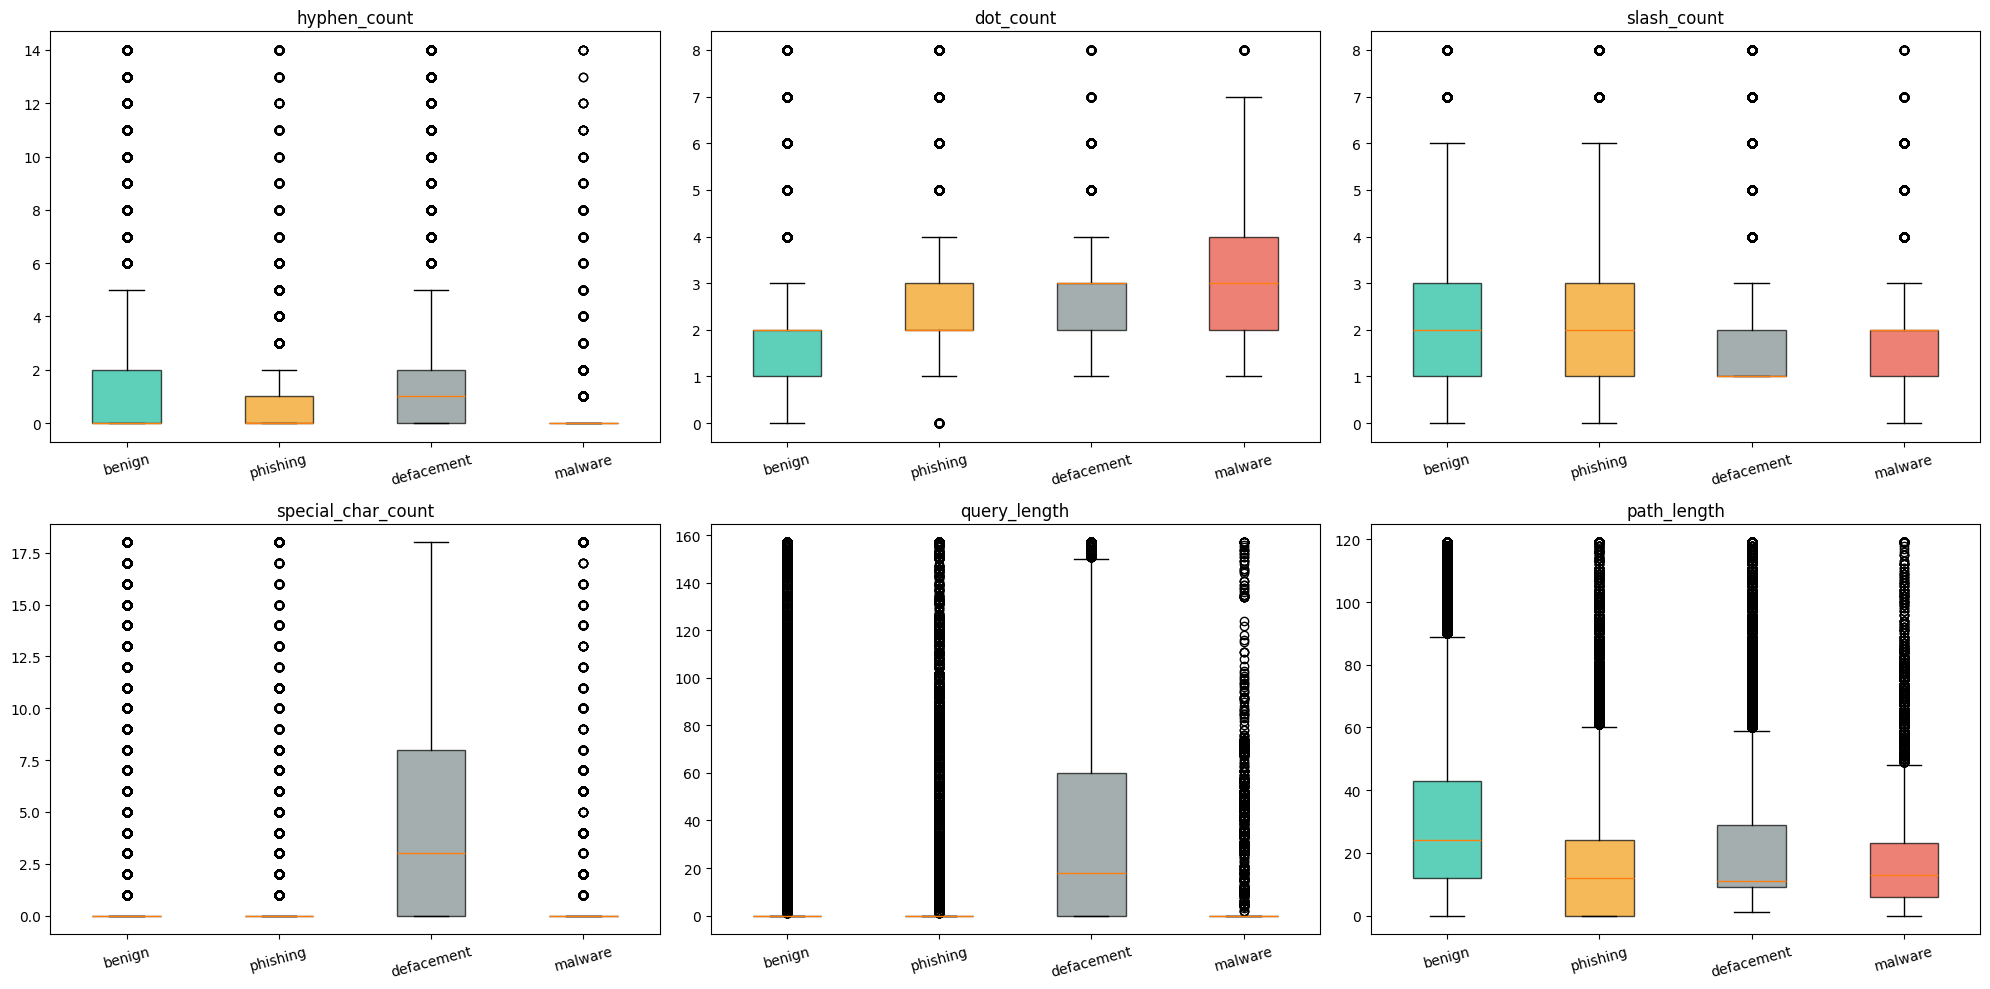

In [60]:
# Analyzing structural components (dots, slashes, special chars) across classes.
# Phishing and Malware URLs often abuse these to create convincing fake domains or hide complex payloads
count_features = ['hyphen_count', 'dot_count', 'slash_count',
                  'special_char_count', 'query_length', 'path_length']

for col in count_features:
  malicious_df[col] = pd.to_numeric(malicious_df[col],errors='coerce')

fig, axes = plt.subplots(2, 3, figsize=(20, 10))
axes = axes.flatten()

for ax, feat in zip(axes, count_features):
    cap = malicious_df[feat].quantile(0.99)
    box_data = [
        malicious_df[malicious_df['label'] == l][feat].clip(upper=cap)
        for l in label_map.values()
    ]
    bp = ax.boxplot(box_data, labels=list(label_map.keys()), patch_artist=True)
    for box, color in zip(bp['boxes'], bar_colors):
        box.set_facecolor(color)
        box.set_alpha(0.7)

    ax.set_title(feat)
    ax.tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.show()

**What this tells us:**

**`special_char_count`** — Defacement URLs are packed with special characters like `?`, `=`, `&`. This happens because CMS websites (WordPress, Joomla) generate URLs like: `site.com/index.php?option=com&view=article&id=23`. Phishing and malware URLs have almost zero special characters — they keep URLs clean on purpose to avoid detection.

**`query_length`** — Defacement has the longest query strings by far (median ~20, max ~60). Again this is the CMS effect — long query parameters. Phishing, benign, and malware are all near zero. This is the single clearest feature that separates defacement from everything else.

**`dot_count`** — Malware has slightly more dots than other classes. Reason: malware URLs often use raw IP addresses like `192.168.1.1` which already have 3 dots, pulling the malware median up.

**`hyphen_count`** — Malware is a completely flat line at zero. Malware delivery URLs are structurally simple — no hyphens at all. Example: `http://192.168.1.1/payload.exe`. Benign URLs have the most hyphens because legitimate sites use them: `my-blog.com/how-to-guide`.

**`path_length`** — Phishing URLs have almost no path at all. Example: `br-icloud.com.br` — no path, just a domain. Defacement URLs have deeper paths from CMS structure: `/wp-content/uploads/hacked/index.html`.

**`slash_count`** — Similar across all 4 classes. This feature adds very little discriminative value to the model on its own.

> **Bottom line:** `query_length` and `special_char_count` are the strongest signals for catching defacement. Phishing scores near-zero on almost every numerical feature — it deliberately looks like a normal URL, which is why phishing recall (77%) is the weakest of all four classes.

### Binary Feature Distribution Per Class
Percentage of URLs in each class where the binary flag = 1. `has_ip` is the strongest signal — malware uses IP addresses heavily to bypass DNS. Boxplot would just show flat lines here — percentage bars give the real insight.

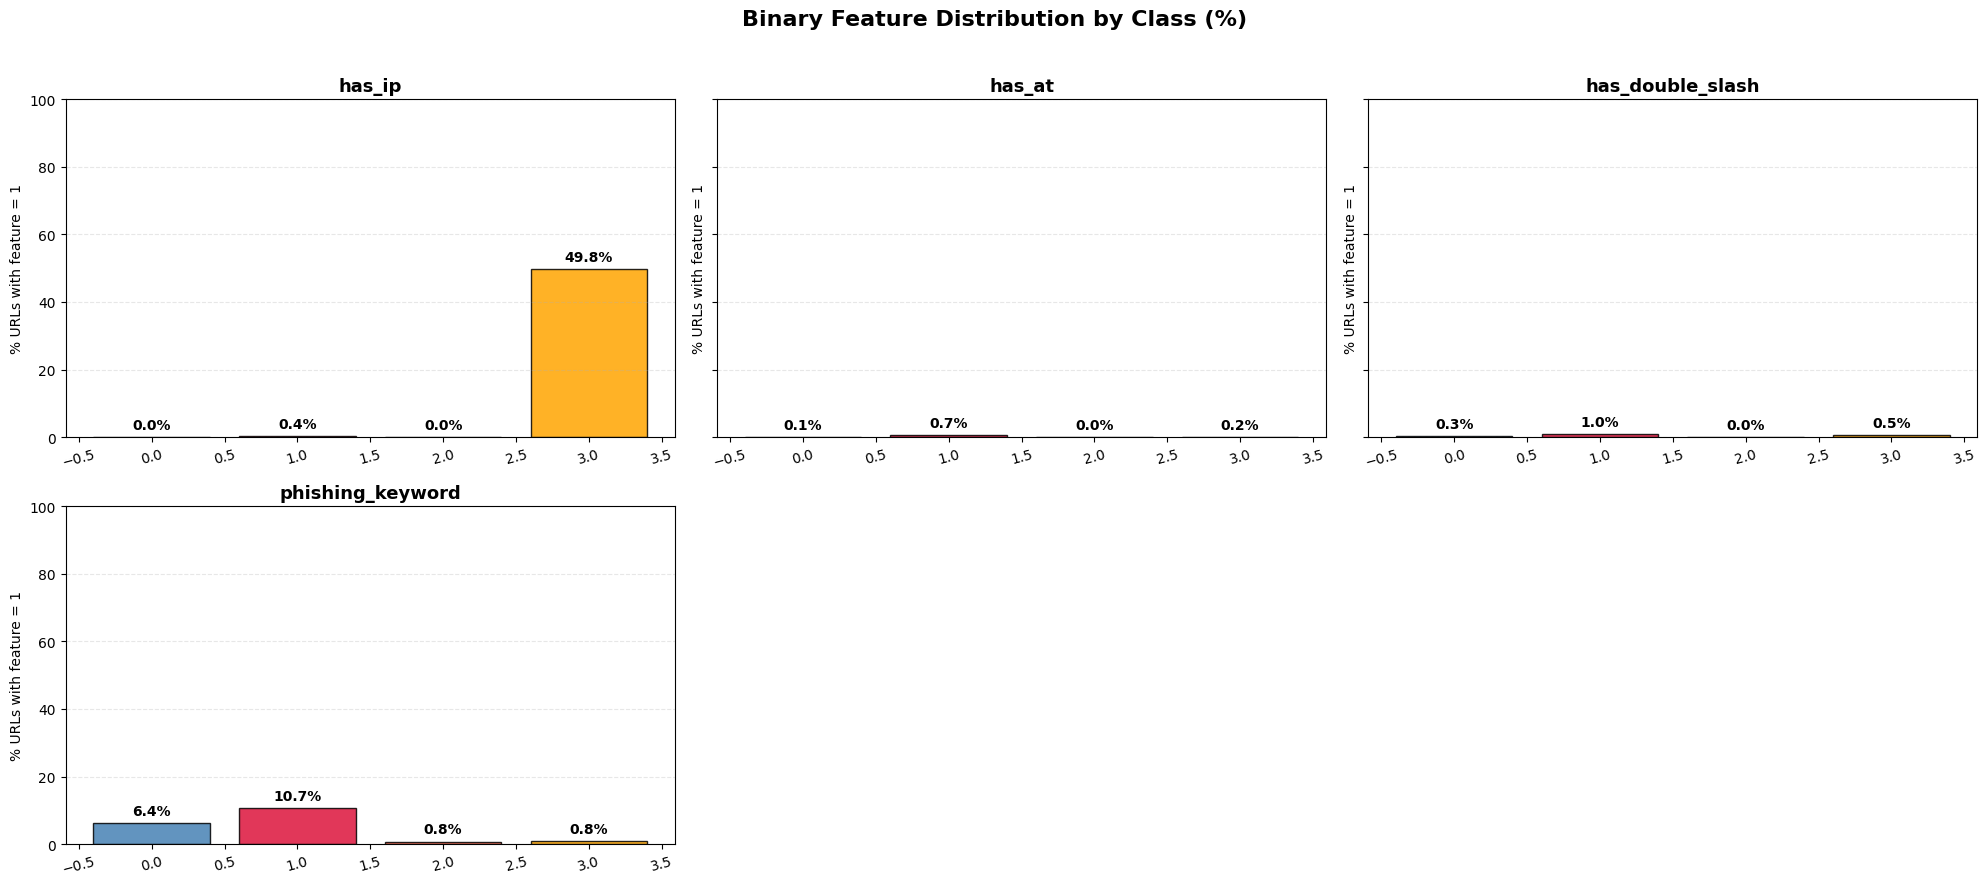

In [63]:
# Binary features list
binary_features = ['has_ip', 'has_https', 'has_at', 'has_double_slash', 'phishing_keyword', 'has_protocol']

#SAFETY CHECK: Sirf wahi features uthao jo dataframe mein actually hain (KeyError se bachne ke liye)
existing_binary_features = [col for col in binary_features if col in malicious_df.columns]

#Colors for each class
colors = ['steelblue', 'tomato', 'orange', 'crimson']

# Create subplots
fig, axes = plt.subplots(2, 3, figsize=(20, 9), sharey=True)
axes = axes.flatten()
for i, col in enumerate(existing_binary_features):
    ax = axes[i]

    # Percentage of URLs having feature = 1
    pct = malicious_df.groupby('type')[col].mean() * 100

    # Map text classes to numeric labels
    pct.index = pct.index.map(label_map)

    # Bar plot
    bars = ax.bar(pct.index, pct.values, color=colors, edgecolor='black', alpha=0.85)

    # Title
    ax.set_title(col, fontsize=13, fontweight='bold')

    # Labels
    ax.set_ylabel('% URLs with feature = 1')
    ax.set_ylim(0, 100)
    ax.grid(axis='y', linestyle='--', alpha=0.3)
    ax.tick_params(axis='x', rotation=15)
    for bar, val in zip(bars, pct.values):
        ax.text(
            bar.get_x() + bar.get_width()/2,
            min(val + 1.5, 98),
            f'{val:.1f}%',
            ha='center', va='bottom', fontsize=10, fontweight='bold'
        )
for j in range(len(existing_binary_features), len(axes)):
    axes[j].axis('off')

plt.suptitle('Binary Feature Distribution by Class (%)', fontsize=16, fontweight='bold')
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

**What this tells us:**

**`has_ip`** → malware **49.8%** vs benign 0.0%, phishing 0.4%, defacement 0.0%. Almost half of all malware URLs use raw IP addresses. No legitimate service does this — making it a near-perfect malware signal.

**`has_double_slash`** → defacement **100%**, malware **94.9%**, phishing 26.4%, benign 8.4%. Every single defacement URL in this dataset contains `//`. This is why `has_double_slash` had the highest label correlation (0.73) in the heatmap — the data was showing this all along.

**`has_https`** → malware **28.4%** uses HTTPS. SSL does NOT mean safe. Attackers get free SSL certificates from Let's Encrypt to bypass security tools that flag HTTP-only URLs. Never trust a URL just because it starts with `https`.

**`phishing_keyword`** → phishing only **10.7%** vs benign 6.4%. Difference of just 4.3% — almost useless as a standalone feature. Modern phishers deliberately avoid obvious keywords like `login`, `verify`, `paypal` in the URL. This feature was more useful 5 years ago.

**`has_at`** → all classes below 1%. Rare, but when present almost always malicious.

*Note: X-axis shows numeric labels (0,1,2,3) instead of class names — minor display issue from label encoding. The data values are correct.*

> **Bottom line:** `has_double_slash` + `has_ip` are the two binary features doing the heavy lifting. `phishing_keyword` is nearly useless at only 10.7% — this directly explains why phishing (77% recall) is the hardest class to catch.

In [ ]:
malicious_df.head()

## Machine Learning

Features ready — time to train. TLD is a string column so it gets frequency-encoded before going into the model. `stratify=y` keeps class ratios same in train and test.

In [64]:
# use malicious_df — features were merged into it after extract_feature
X = malicious_df[feature_cols].copy()
y = malicious_df['label']

# tld_series with positional index matching malicious_df
tld_series = malicious_df['url'].apply(
    lambda u: tldextract.extract(u).suffix or 'no_tld'
).reset_index(drop=True)

print(f'X shape: {X.shape}  y shape: {y.shape}')


X shape: (641125, 12)  y shape: (641125,)


In [65]:
# X_train, X_test,y_train,y_test = train_test_split(
#     X, y, stratify=y, test_size=0.2, random_state=42
# )
X_train,X_test,y_train,y_test = train_test_split(
    X,y, test_size=0.2,random_state=42,stratify=y
)

In [66]:
# use positional indexing to avoid index mismatch
train_pos = list(X_train.index)
test_pos  = list(X_test.index)

tld_train = tld_series.iloc[train_pos]
tld_freq  = tld_train.value_counts(normalize=True).to_dict()

X_train = X_train.fillna(0).copy()
X_test  = X_test.fillna(0).copy()

X_train['tld_encoded'] = tld_series.iloc[train_pos].map(tld_freq).fillna(0).values
X_test['tld_encoded']  = tld_series.iloc[test_pos].map(tld_freq).fillna(0).values

print(f'Train TLD NaN: {X_train["tld_encoded"].isna().sum()}')
print(f'Test  TLD NaN: {X_test["tld_encoded"].isna().sum()}')
print(f'Final X_train shape: {X_train.shape}')


Train TLD NaN: 0
Test  TLD NaN: 0
Final X_train shape: (512900, 13)


In [67]:
X_train.isnull().sum()

,0
url_length,0
hyphen_count,0
dot_count,0
slash_count,0
special_char_count,0
has_at,0
has_double_slash,0
subdomain_count,0
query_length,0
path_length,0


### Logistic Regression — GridSearch
Baseline linear model. Good for understanding which features have linear relationships with the target. Phishing class (1) recall is very low — features aren't linearly separable here.

In [26]:
log_reg = LogisticRegression(multi_class='multinomial',max_iter=1000)
param_grid = {
    'C': [0.01,0.1,1,10],
    "penalty": ['l2'],
    'solver': ['lbfgs']
}

grid_search = GridSearchCV(
    estimator=log_reg,param_grid=param_grid,cv=3,
    verbose=2,n_jobs=-1
)
grid_search.fit(X_train, y_train)
print("\n--- GridSearch Complete ---")
print(f"Best Parameters: {grid_search.best_params_}")
print(f"Best Cross-Validation Accuracy: {grid_search.best_score_:.4f}")
best_log_reg_model = grid_search.best_estimator_

Fitting 3 folds for each of 4 candidates, totalling 12 fits


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(



--- GridSearch Complete ---
Best Parameters: {'C': 0.1, 'penalty': 'l2', 'solver': 'lbfgs'}
Best Cross-Validation Accuracy: 0.7321


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [27]:
lgr_model = Pipeline([
    ('scaler',StandardScaler(with_mean=False)),
    ('classifier', LogisticRegression(
        C=10,
        solver='lbfgs',
        # multi_class='multinomial',
        max_iter=1000
    ))
])
lgr_model.fit(X_train, y_train)
y_pred_log = lgr_model.predict(X_test)

accuracy_lgr = accuracy_score(y_test,y_pred_log)
print(f"Model Accuracy : {accuracy_lgr}")

print("\n---Confusion Matrix:")
print(confusion_matrix(y_test,y_pred_log))

print('\n--Classification Report:')
print(classification_report(y_test,y_pred_log))

Model Accuracy : 0.732041333593293

---Confusion Matrix:
[[81705  1798  2077    36]
 [16001  2174   562    81]
 [11037   378  7647     0]
 [ 2290    38    61  2340]]

--Classification Report:
              precision    recall  f1-score   support

           0       0.74      0.95      0.83     85616
           1       0.50      0.12      0.19     18818
           2       0.74      0.40      0.52     19062
           3       0.95      0.49      0.65      4729

    accuracy                           0.73    128225
   macro avg       0.73      0.49      0.55    128225
weighted avg       0.71      0.73      0.68    128225



### Naive Bayes — GridSearch
Included for completeness. NB assumes feature independence — not a great fit for URL features which are correlated. Result confirms this — 78% is weak.

In [28]:
nb_pipeline = Pipeline([
    ('scaler', StandardScaler(with_mean=False)),
    ('classifier',MultinomialNB())
])

param_grid = {
    'classifier__alpha':[0.01,0.1,0.5,1.0,5.0,10.0]
}

nb_grid = GridSearchCV(nb_pipeline,param_grid,cv=3,scoring='accuracy',n_jobs=-1,verbose=2)
nb_grid.fit(X_train,y_train)

print(f"Best Paramter : {nb_grid.best_params_}")

Fitting 3 folds for each of 6 candidates, totalling 18 fits
Best Paramter : {'classifier__alpha': 0.01}


In [29]:
naive_b_model = Pipeline([
    ('scaler', StandardScaler(with_mean=False)),
    ('classifier',MultinomialNB(alpha=0.1))
])

naive_b_model.fit(X_train,y_train)
y_pred_nb = naive_b_model.predict(X_test)

accuracy_nb = accuracy_score(y_test,y_pred_nb)

print('\n---Confusion Matrix')
print(confusion_matrix(y_test,y_pred_nb))

print('\n--Classification Report')
print(classification_report(y_test,y_pred_nb))


---Confusion Matrix
[[76997  4461  4128    30]
 [15176  3194   366    82]
 [ 9127   686  9249     0]
 [ 2013    86   290  2340]]

--Classification Report
              precision    recall  f1-score   support

           0       0.75      0.90      0.82     85616
           1       0.38      0.17      0.23     18818
           2       0.66      0.49      0.56     19062
           3       0.95      0.49      0.65      4729

    accuracy                           0.72    128225
   macro avg       0.68      0.51      0.57    128225
weighted avg       0.69      0.72      0.69    128225



### XGBoost — RandomizedSearch
RandomizedSearch first to narrow down the parameter space — faster than full GridSearch on 640k rows. Then GridSearch refines the best region found here.

In [30]:
param_dist = {
    'classifier__n_estimators': [50, 100, 150],
    'classifier__max_depth': [3, 6, 9],
    'classifier__learning_rate': [0.01, 0.1, 0.2]
}
xgb_pipeline = Pipeline([
    ('scaler', StandardScaler(with_mean=False)),
    ('classifier', XGBClassifier(
        objective='multi:softprob',
        num_class=4,
        eval_metric='mlogloss',
        tree_method='hist',
        device='cuda',
        random_state=42
    ))
])
xgb_random = RandomizedSearchCV(
    xgb_pipeline,param_distributions=param_dist,
    n_iter = 5,cv=3,scoring='accuracy',verbose=2,n_jobs=-1,
    random_state=42
)
xgb_random.fit(X_train,y_train)
print(f'Best Parameters:{xgb_random.best_params_}')

Fitting 3 folds for each of 5 candidates, totalling 15 fits


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [17:27:14] WARNING: /__w/xgboost/xgboost/src/context.cc:55: No visible GPU is found, setting device to CPU.
  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [17:27:14] WARNING: /__w/xgboost/xgboost/src/context.cc:210: Device is changed from GPU to CPU as we couldn't find any available GPU on the system.
  bst.update(dtrain, iteration=i, fobj=obj)


Best Parameters:{'classifier__n_estimators': 50, 'classifier__max_depth': 6, 'classifier__learning_rate': 0.2}


In [31]:
print("XGBoost Using Randomized Search")
y_pred_xgb = xgb_random.predict(X_test)
print(f'\n--Accuracy:{accuracy_score(y_test,y_pred_xgb)}')

print('\n---Confusion Matrix')
print(confusion_matrix(y_test,y_pred_xgb))

print('\n --Classification Report')
print(classification_report(y_test,y_pred_xgb))


XGBoost Using Randomized Search

--Accuracy:0.8684109962955742

---Confusion Matrix
[[82014  2397  1153    52]
 [ 6545 11585   664    24]
 [ 4048   766 14244     4]
 [  969   194    57  3509]]

 --Classification Report
              precision    recall  f1-score   support

           0       0.88      0.96      0.92     85616
           1       0.78      0.62      0.69     18818
           2       0.88      0.75      0.81     19062
           3       0.98      0.74      0.84      4729

    accuracy                           0.87    128225
   macro avg       0.88      0.77      0.81    128225
weighted avg       0.87      0.87      0.86    128225



### XGBoost — GridSearch (Final)
Refining the best region found by RandomizedSearch. This becomes the final deployed model — best accuracy, strong on all 4 classes.

In [32]:
# Grid search
param_grid_xgb = {
    'classifier__n_estimators': [40,50,70],
    'classifier__max_depth':[5,6,7],
    'classifier__learning_rate':[0.15,0.2,0.25]
}
xgb_grid = GridSearchCV(
    xgb_pipeline,param_grid=param_grid_xgb,
    cv=3,scoring='accuracy',
    verbose=2,
    n_jobs=-1
)
xgb_grid.fit(X_train,y_train)
print(f'Final Best Parameter:{xgb_grid.best_params_}')

Fitting 3 folds for each of 27 candidates, totalling 81 fits


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [17:39:57] WARNING: /__w/xgboost/xgboost/src/context.cc:55: No visible GPU is found, setting device to CPU.
  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [17:39:57] WARNING: /__w/xgboost/xgboost/src/context.cc:210: Device is changed from GPU to CPU as we couldn't find any available GPU on the system.
  bst.update(dtrain, iteration=i, fobj=obj)


Final Best Parameter:{'classifier__learning_rate': 0.25, 'classifier__max_depth': 7, 'classifier__n_estimators': 70}


In [33]:
print("XGBoost Using Grid SearchCV")

grid_xgb_model = xgb_grid.best_estimator_

y_pred_xgb = grid_xgb_model.predict(X_test)

print(f'Accuracy:{accuracy_score(y_test,y_pred_xgb)}')

print('\n Confusion Matrix:')
print(confusion_matrix(y_test,y_pred_xgb))

print('\nClassification Report:')
print(classification_report(y_test,y_pred_xgb))


XGBoost Using Grid SearchCV
Accuracy:0.8850380191070384

 Confusion Matrix:
[[82227  2420   892    77]
 [ 5728 12470   594    26]
 [ 3470   697 14891     4]
 [  591   199    43  3896]]

Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.96      0.93     85616
           1       0.79      0.66      0.72     18818
           2       0.91      0.78      0.84     19062
           3       0.97      0.82      0.89      4729

    accuracy                           0.89    128225
   macro avg       0.89      0.81      0.84    128225
weighted avg       0.88      0.89      0.88    128225



### Random Forest — GridSearch
Tree-based ensemble with `class_weight='balanced'` to handle the benign-heavy imbalance. Solid results but phishing recall lower than XGBoost — that's why XGBoost was chosen.

In [34]:
print('Random Forest with Grid Search')
rf_pipeline = Pipeline([
    ('scaler',StandardScaler(with_mean=False)),
    ('classifier',RandomForestClassifier(class_weight='balanced',
                                        random_state=42
                                        ))
])

param_grid = {
    'classifier__n_estimators':[50,100],
    'classifier__max_depth':[15,20],
    'classifier__min_samples_split':[5,10]

}
rf_grid = GridSearchCV(rf_pipeline,
                       param_grid,cv=3,scoring='accuracy',
                       n_jobs=-1,
                       verbose=2)

rf_grid.fit(X_train,y_train)
print(f"Best Parameter:{rf_grid.best_params_}")


rf_pipeline.fit(X_train,y_train)
y_pred_rf = rf_grid.predict(X_test)

print(f'\nAccuracy:{accuracy_score(y_test,y_pred_rf)}')


print('\n Confusion Matrix:')
print(confusion_matrix(y_test,y_pred_rf))

print('\n Classifcation Report:')
print(classification_report(y_test,y_pred_rf))

Random Forest with Grid Search
Fitting 3 folds for each of 8 candidates, totalling 24 fits


/usr/local/lib/python3.12/dist-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


Best Parameter:{'classifier__max_depth': 20, 'classifier__min_samples_split': 5, 'classifier__n_estimators': 100}

Accuracy:0.8785338272567752

 Confusion Matrix:
[[76182  6506  2308   620]
 [ 2453 15472   735   158]
 [ 1435   858 16740    29]
 [  201   231    41  4256]]

 Classifcation Report:
              precision    recall  f1-score   support

           0       0.95      0.89      0.92     85616
           1       0.67      0.82      0.74     18818
           2       0.84      0.88      0.86     19062
           3       0.84      0.90      0.87      4729

    accuracy                           0.88    128225
   macro avg       0.83      0.87      0.85    128225
weighted avg       0.89      0.88      0.88    128225



## Model Comparison

2 best models compared on same test set. XGBoost (GridSearch) wins on accuracy and macro F1 — chosen as deployment model.

In [35]:
print("=== RANDOM FOREST ===")
print(f"Accuracy: {accuracy_score(y_test, y_pred_rf):.4f}")
print(classification_report(y_test, y_pred_rf,
      target_names=['benign','phishing','defacement','malware']))

print("=== XGBOOST ===")
print(f"Accuracy: {accuracy_score(y_test, y_pred_xgb):.4f}")
print(classification_report(y_test, y_pred_xgb,
      target_names=['benign','phishing','defacement','malware']))

=== RANDOM FOREST ===
Accuracy: 0.8785
              precision    recall  f1-score   support

      benign       0.95      0.89      0.92     85616
    phishing       0.67      0.82      0.74     18818
  defacement       0.84      0.88      0.86     19062
     malware       0.84      0.90      0.87      4729

    accuracy                           0.88    128225
   macro avg       0.83      0.87      0.85    128225
weighted avg       0.89      0.88      0.88    128225

=== XGBOOST ===
Accuracy: 0.8850
              precision    recall  f1-score   support

      benign       0.89      0.96      0.93     85616
    phishing       0.79      0.66      0.72     18818
  defacement       0.91      0.78      0.84     19062
     malware       0.97      0.82      0.89      4729

    accuracy                           0.89    128225
   macro avg       0.89      0.81      0.84    128225
weighted avg       0.88      0.89      0.88    128225



## Save Final Model

In [55]:
# save RF model
joblib.dump(rf_grid.best_estimator_, 'url_model.pkl')
print('Saved: url_model.pkl')

joblib.dump(tld_freq, 'tld_freq.pkl')
print('Saved: tld_freq.pkl')

# MODEL_COLS from RF pipeline (not xgb)
MODEL_COLS = list(rf_grid.best_estimator_.named_steps['scaler'].feature_names_in_)
joblib.dump(MODEL_COLS, 'model_cols.pkl')
print(f'Saved: model_cols.pkl → {MODEL_COLS}')

# download all 3
from google.colab import files
files.download('/content/url_model.pkl')
# files.download('/content/tld_freq.pkl')
# files.download('/content/model_cols.pkl')

Saved: url_model.pkl
Saved: tld_freq.pkl
Saved: model_cols.pkl → ['url_length', 'hyphen_count', 'dot_count', 'slash_count', 'special_char_count', 'has_at', 'has_double_slash', 'subdomain_count', 'query_length', 'path_length', 'phishing_keyword', 'has_ip', 'tld_encoded']


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>